# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
from Tools.DatasetTools.Commoms import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor
from mendeleev import element

In [2]:
from mp_api.client import MPRester

# options 

In [3]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
case = 'POSCAR-initial'  # 'POSCAR-relaxed']
rescale_by_atoms = True #  False]
subcase = 'rescaled' #  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'FurtherCuratedParsedBriefSummary.pkl')

In [4]:
MP_keys = {'Fe' : 'mp-13', 'Mo' : 'mp-129'}

In [5]:
BS = pd.read_pickle(CuratedBS)

In [6]:
bcc_bs = BS.loc[BS.index.str.contains('Fe.*bcc.*FM', regex=True)]

In [7]:
bcc_bs

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv2.bcc-cubic.FM,bulk bcc-cubic.FM,11.367016 A,-8.254843,187.308419 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.015,0,1,...,,2,0,2,1.0,0.0,0.0,0.0,0.0,bcc


In [8]:
Features = Featurizer(BS)

chech that the chemistry resetting is correct!

## atom volume lists from materials projects 

In [9]:
atom_volume_keys = {}
with MPRester("vqAj4QNIdoBrVn4ykLdhYk5FsP2eF8oM") as mpr:
    for atom, key in MP_keys.items():
        result =mpr.summary.search(material_ids=[key])[0]
        total_vol = result.volume
        nsites = result.nsites
        atom_volume_keys[atom] = total_vol/nsites

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
atom_volume_keys

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [11]:
#Features = Featurizer(BS)

# Sort Poscar files

In [12]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [13]:
sublatticesortersfile

'Fe-Mo/Atomsobjects/SORTERS.pkl'

In [14]:
if not os.path.exists(sublatticesortersfile): # need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
    SORTERS.to_pickle(sublatticesortersfile)
    SUBLATICETAGS.to_pickle(sublatticetagfile)
else:
    SORTERS = pd.read_pickle(sublatticesortersfile)
    SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

# Now I have to pick the atoms objects

In [15]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
#database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{dataset}-{case}-{subcase}-AtomsObjects.pkl')

In [16]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=dataset,rescale_by_atoms=True, reset_chemistry=True,file_filter = 'initial$', element_volumes=atom_volume_keys)
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

In [17]:
allindex = Atoms_Objects.index.intersection(BS.index)

In [18]:
Atoms_Objects = Atoms_Objects.loc[allindex]

In [19]:
Atoms_Objects.to_pickle(AtomsFile)

In [20]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [21]:
difference = BS.index.difference(Atoms_Objects.index)

In [22]:
difference

Index([], dtype='object')

#  visualization of some structures

In [23]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [24]:
from ase.visualize.plot import plot_atoms

In [25]:
Atoms_Objects

,atoms,file
Fe_pv8.A15.FM,"(Atom('Fe', [0.0, 0.0, 0.0], index=0), Atom('F...",[Fe-Mo/rawdata/Fe_pv/bulk/A15.FM/relax/xc=PBE-...
Fe_pv12.C14.FM,"(Atom('Fe', [0.78550618543227, 1.5758548685527...",[Fe-Mo/rawdata/Fe_pv/bulk/C14.FM/relax/xc=PBE-...
Fe_pv24Mo_sv5.chi-BBAA.FM,"(Atom('Fe', [0.47595035926088963, 0.4759503592...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/chi-BBAA.FM/re...
Fe_pv25Mo_sv4.chi-ABAA.FM,"(Atom('Fe', [1.7583870377638002, 1.75838703776...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/chi-ABAA.FM/re...
Fe_pv30.sigma.FM,"(Atom('Fe', [1.6068430570857728, 1.60684305708...",[Fe-Mo/rawdata/Fe_pv/bulk/sigma.FM/relax/xc=PB...
...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,"(Atom('Fe', [1.7583870377638002, 1.75838703776...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/chi-ABAA/relax...
Fe_pv16Mo_sv8.C36-BBAAA.NM,"(Atom('Fe', [2.796698489689065, 0.702061587697...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C36-BBAAA/rela...
Fe_pv8Mo_sv4.C14-BAA.NM,"(Atom('Fe', [0.40764339428921986, 0.7060587410...",[Fe-Mo/rawdata/Fe_pv-Mo_sv/bulk/C14-BAA/relax/...
Fe_pv4.fcc-cubic.NM,"(Atom('Fe', [0.0, 1.8035979594728138, 1.803597...",[Fe-Mo/rawdata/Fe_pv/bulk/fcc-cubic/relax/xc=P...


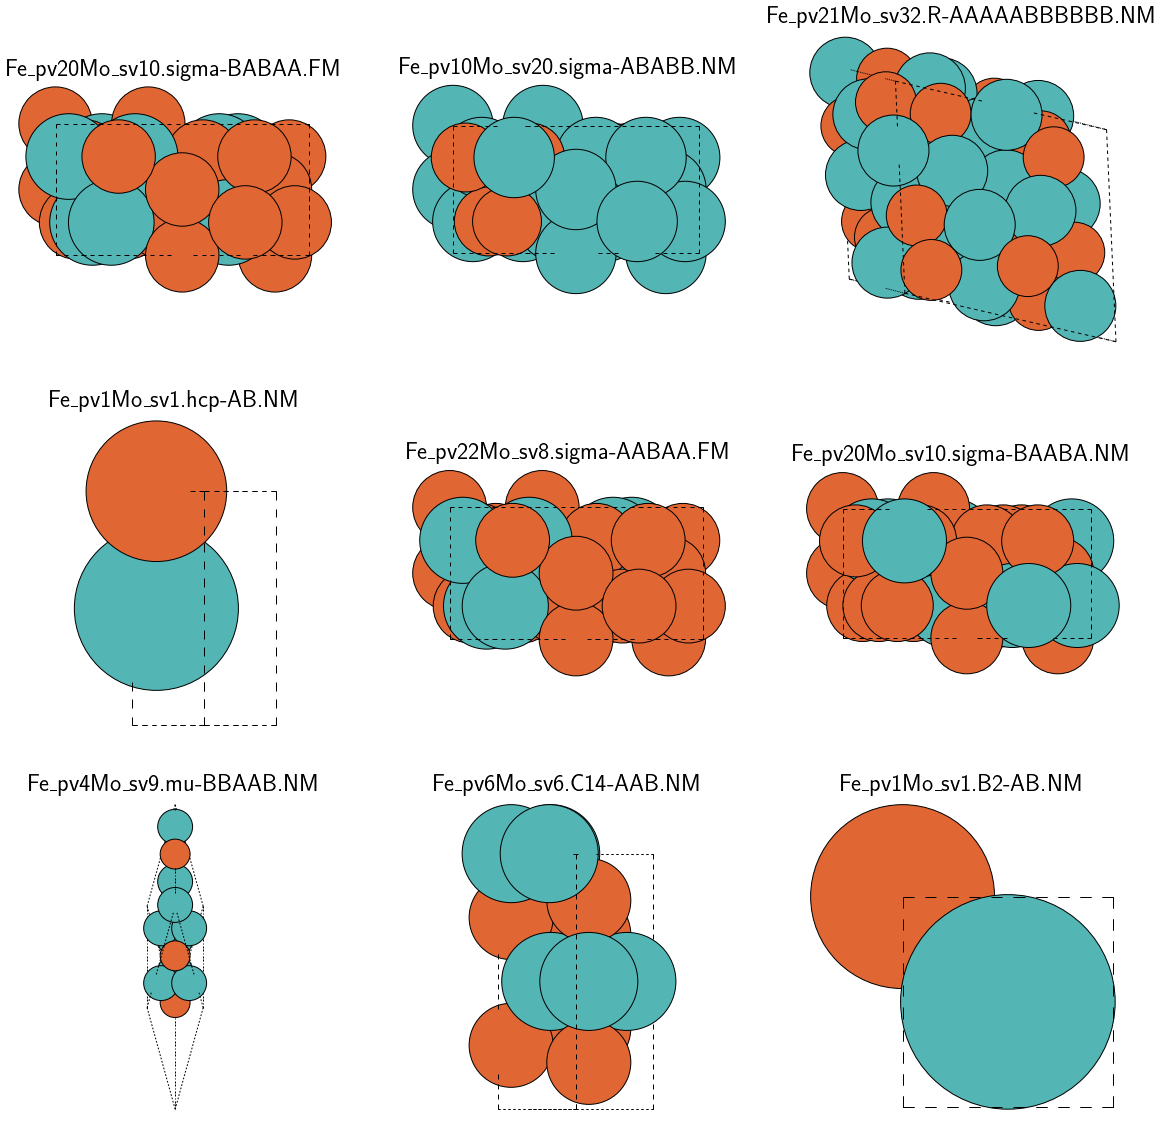

In [26]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [27]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

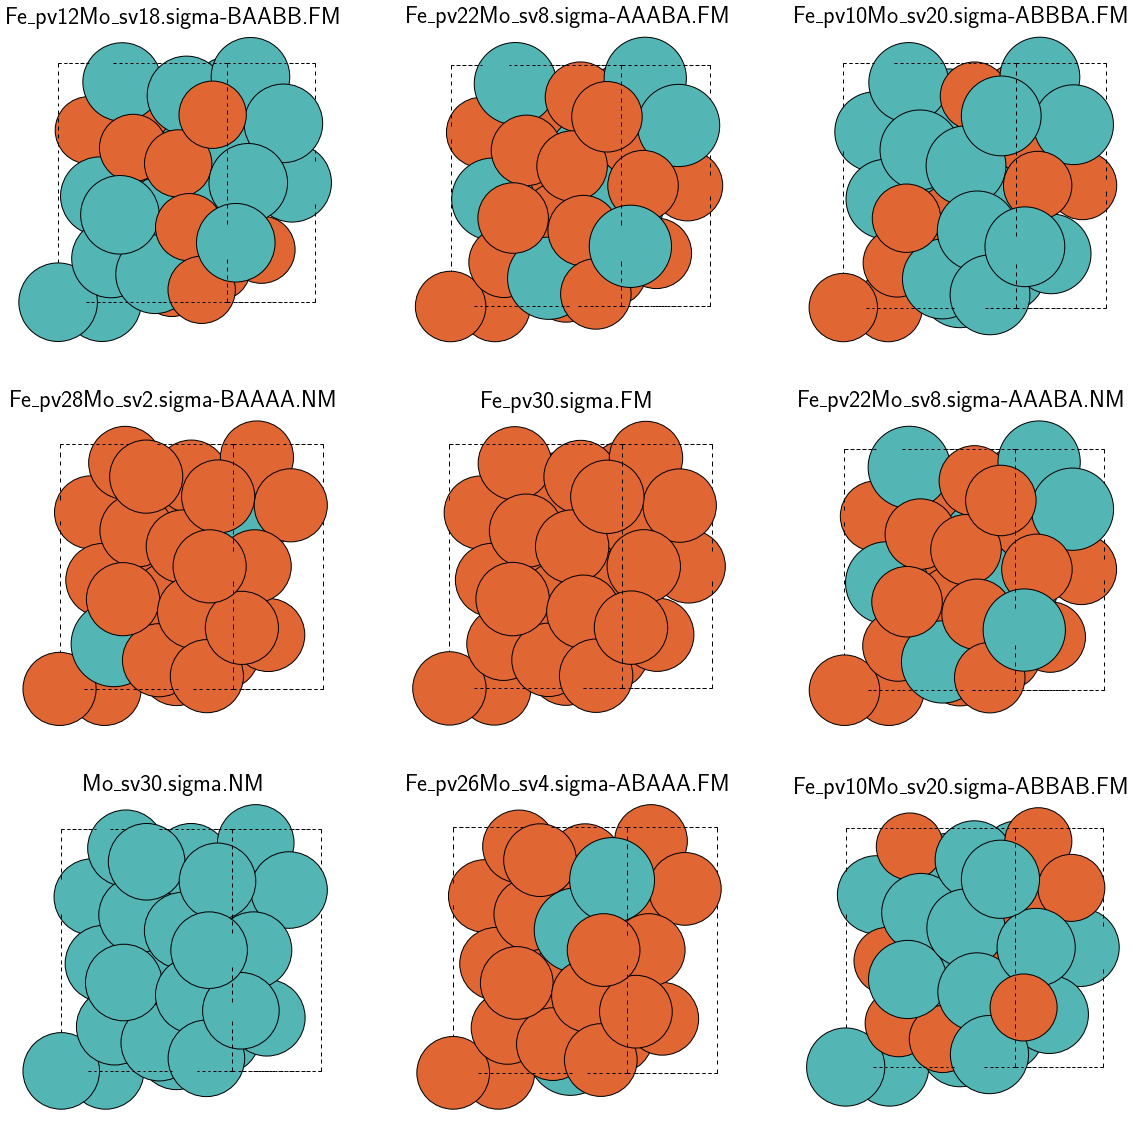

In [28]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [29]:
Problems = BS.index.difference(Atoms_Objects.index)

In [30]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase


In [31]:
GoodBS = BS.loc[Atoms_Objects.index]

In [32]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,8,0,8,1.000000,0.000000,0.085084,0.085084,0.085084,A15
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,12,0,12,1.000000,0.000000,0.148852,0.148852,0.148852,C14
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,24,5,29,0.827586,0.172414,0.057889,0.057889,0.057889,chi
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,25,4,29,0.862069,0.137931,0.063321,0.063321,0.063321,chi
Fe_pv30.sigma.FM,bulk sigma.FM,11.888048 A,-8.179761,144.498096 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.019,0,1,...,,30,0,30,1.000000,0.000000,0.075082,0.075082,0.075082,sigma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,25,4,29,0.862069,0.137931,0.118668,0.057656,-0.010508,chi
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,16,8,24,0.666667,0.333333,0.029765,-0.017418,-0.070131,C36
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,4,12,0.666667,0.333333,0.014403,-0.032780,-0.085493,C14
Fe_pv4.fcc-cubic.NM,bulk fcc-cubic,10.248696 A,-8.104999,283.740438 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,4,0,4,1.000000,0.000000,0.149844,0.079070,0.000000,fcc


In [33]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [34]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [35]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

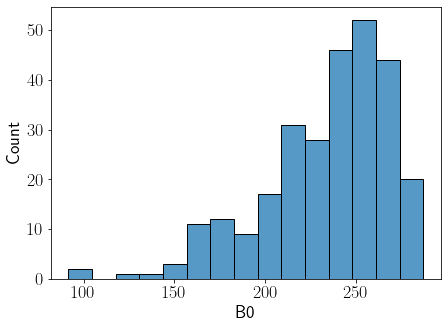

In [36]:
sns.histplot(BS['B0'])

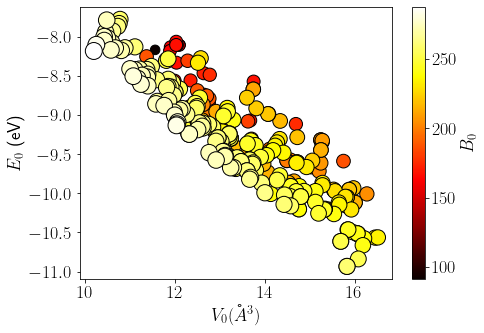

In [37]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

In [38]:
volumes = Atoms_Objects['atoms'].map(lambda a: a.get_volume())/BS['num_atoms']

# Atomic volumes vs dft

In [39]:
BS.query('num_atoms == 1').groupby('E0').min('E0')#['V0']#reset_index()

,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
E0,,,,,,,,,,,
-10.932826,1,259.504388,15.828881,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.932791,1,257.418673,15.827863,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.511039,1,239.489255,16.059116,1,0,1,0.0,1.0,0.421787,0.421787,0.421787
-8.107004,1,167.191413,12.025934,1,0,1,1.0,0.0,0.342800,0.342800,0.342800
-7.790673,1,274.074843,10.480776,1,0,1,1.0,0.0,0.464170,0.393396,0.314326


In [40]:
Fe_unary = BS.query('num_atoms == 1 and Fe_pv == 1')

In [41]:
V_GS_Fe = Fe_unary[Fe_unary.E0 == Fe_unary.E0.min()].V0

In [42]:
V_GS_Fe

Fe_pv1.fcc.FM    12.025934
Name: V0, dtype: float64

In [43]:
Mo_unary = BS.query('num_atoms == 1 and Mo_sv == 1')

In [44]:
V_GS_Mo = Mo_unary[Mo_unary.E0 == Mo_unary.E0.min()].V0

In [45]:
V_GS_Mo

Mo_sv1.bcc.NM    15.828881
Name: V0, dtype: float64

In [46]:
import mendeleev

In [47]:
Mo = mendeleev.element('Mo')#.metallic_radius

In [48]:
Mo.atomic_volume

9.4

In [49]:
norm = plt.Normalize(BS['Fe_pv'].min(), BS['Fe_pv'].max())

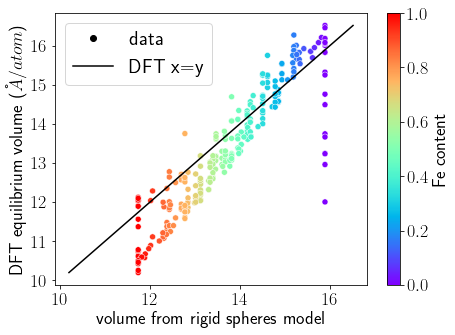

In [50]:
ax  = sns.scatterplot(volumes, BS['V0'], hue=BS['Fe_pv'], palette = 'rainbow', label='data', legend='brief', markers=BS.Phase)
ax = sns.lineplot(BS['V0'], BS['V0'],ax = ax, color='k', label='x=y', legend='brief')#, hue=BS['Fe_pv'], palette='rainbow')
sm = plt.cm.ScalarMappable(norm=norm, cmap='rainbow')
sm.set_array([])
ax.set_ylabel(r'DFT equilibrium volume ($ \AA /atom $)')
ax.set_xlabel('volume from rigid spheres model')
#ax.legend(['data', 'x=y'])
handles = [
    plt.Line2D([0],[0], marker='o', linestyle='', c='k'),
    plt.Line2D([0],[0],linestyle='-', c='k')
]
labels=[
    'data',
    'DFT x=y'
]
ax.legend(handles, labels)
cbar = ax.figure.colorbar(sm)
cbar.set_label('Fe content')
plt.savefig(f'{dataset}/graphs/{dataset}-dftV_vs_gressV.pdf')

In [51]:
BS['V0'].max()

16.515851

In [52]:
volumes[volumes > volumes.max() - 0.1]

Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM    15.813184
Mo_sv1.bcc.FM                     15.891628
Mo_sv1.bcc.NM                     15.891628
Mo_sv1.fcc.NM                     15.891628
Mo_sv12.C14.NM                    15.891628
Mo_sv13.mu.FM                     15.891628
Mo_sv13.mu.NM                     15.891628
Mo_sv2.hcp.FM                     15.891628
Mo_sv2.hcp.NM                     15.891628
Mo_sv24.C36.FM                    15.891628
Mo_sv24.C36.NM                    15.891628
Mo_sv29.chi.FM                    15.891628
Mo_sv29.chi.NM                    15.891628
Mo_sv30.sigma.FM                  15.891628
Mo_sv30.sigma.NM                  15.891628
Mo_sv4.fcc-cubic.FM               15.891628
Mo_sv4.fcc-cubic.NM               15.891628
Mo_sv53.R.NM                      15.891628
Mo_sv6.C15.NM                     15.891628
Mo_sv8.A15.FM                     15.891628
Mo_sv8.A15.NM                     15.891628
dtype: float64

In [53]:
volumes[volumes < volumes.min() + 0.1]

Fe_pv1.bcc.NM                     11.734084
Fe_pv1.fcc.FM                     11.734084
Fe_pv12.C14.FM                    11.734084
Fe_pv12.C14.NM                    11.734084
Fe_pv13.mu.FM                     11.734084
Fe_pv13.mu.NM                     11.734084
Fe_pv2.bcc-cubic.FM               11.734084
Fe_pv2.hcp.FM                     11.734084
Fe_pv2.hcp.NM                     11.734084
Fe_pv24.C36.FM                    11.734084
Fe_pv24.C36.NM                    11.734084
Fe_pv29.chi.NM                    11.734084
Fe_pv30.sigma.FM                  11.734084
Fe_pv30.sigma.NM                  11.734084
Fe_pv30.sigma_Fe_pv.FM            11.734084
Fe_pv4.fcc-cubic.NM               11.734084
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM    11.812528
Fe_pv53.R.NM                      11.734084
Fe_pv6.C15.FM                     11.734084
Fe_pv6.C15.NM                     11.734084
Fe_pv8.A15.FM                     11.734084
Fe_pv8.A15.NM                     11.734084
dtype: float64

In [54]:
BS.index.str.contains('FM').sum()

103

In [55]:
BS.index.str.contains('NM').sum()

174

In [56]:
febcc = Atoms_Objects.atoms[Atoms_Objects.index.str.contains(r'Fe.*bcc.*FM', regex=True)]

In [57]:
len(febcc[0])

2

In [58]:
BS.loc[febcc.index].num_atom_A

Fe_pv2.bcc-cubic.FM    2
Name: num_atom_A, dtype: int64